In [9]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../data/churn.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

model = joblib.load("../models/best_model.pkl")

preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

print(classifier)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [11]:
X_processed = preprocessor.transform(X)

import shap

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_processed)

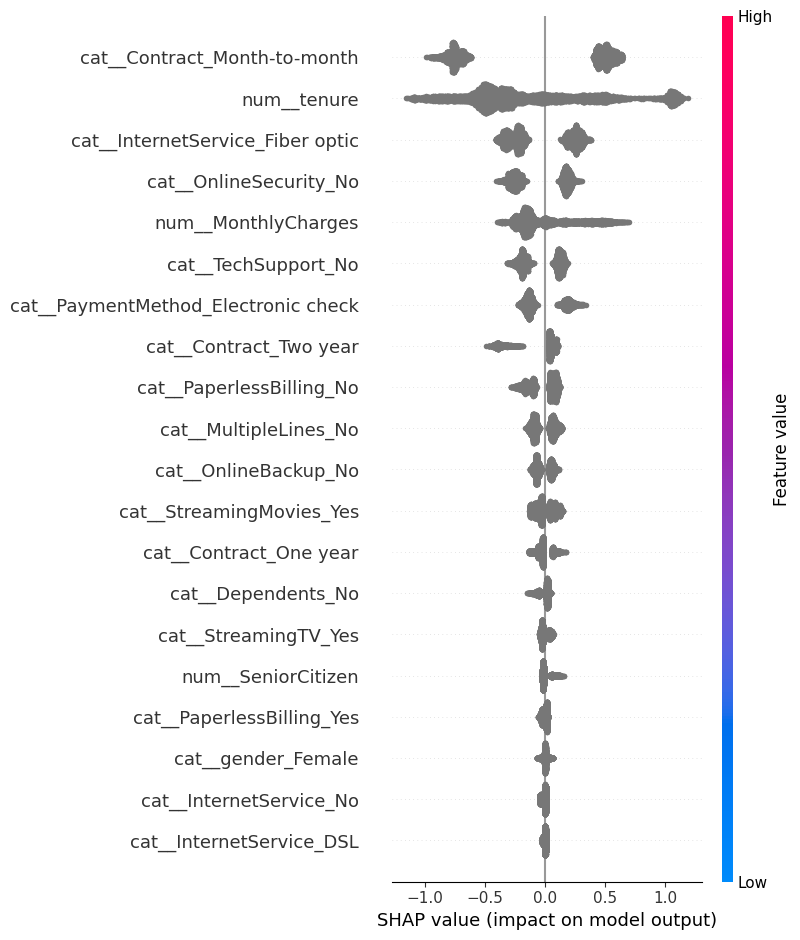

In [12]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(shap_values, X_processed, feature_names=feature_names)

## 🔍 Model Explainability (SHAP Analysis)

To understand the behavior of the final model (XGBoost), SHAP (SHapley Additive exPlanations) was used to analyze feature impact on churn predictions.

### 📊 Key Drivers of Churn

The most influential features identified by the model include:

- **Contract Type (Month-to-Month)**  
  Customers on month-to-month contracts have a significantly higher probability of churning.

- **Tenure**  
  Customers with shorter tenure are much more likely to churn, while long-term customers are more stable.

- **Monthly Charges**  
  Higher monthly charges are associated with increased churn risk.

- **Online Security (No)**  
  Customers without online security services show higher churn likelihood.

- **Internet Service (Fiber Optic)**  
  Fiber optic users tend to have higher churn risk, possibly due to higher costs or expectations.

- **Tech Support (No)**  
  Lack of technical support is associated with increased churn.

- **Payment Method (Electronic Check)**  
  Customers using electronic check payments show higher churn probability.

---

### 🎯 Conclusion

The SHAP analysis confirms that the model is not only accurate but also interpretable, identifying meaningful and actionable drivers behind customer churn.